Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Similarity Matrix:
 [[ 1.0000001   0.4290316   0.4648207   0.30814058 -0.00141839  0.00751817
   0.01140194  0.05660526  0.03231511 -0.05402429]
 [ 0.4290316   1.0000004   0.56027603  0.35601842  0.01576487  0.05102912
   0.08269219  0.03531999  0.01415059 -0.08648302]
 [ 0.4648207   0.56027603  1.0000001   0.3526856   0.01609722  0.01945466
   0.00526458  0.01752815  0.02257345 -0.03775842]
 [ 0.30814058  0.35601842  0.3526856   1.0000002  -0.04468837  0.01535539
  -0.00104519  0.07945377  0.09426201  0.10957836]
 [-0.00141839  0.01576487  0.01609722 -0.04468837  1.0000002   0.4479195
   0.43976772 -0.00239607  0.04137949  0.08651273]
 [ 0.00751817  0.05102912  0.01945466  0.01535539  0.4479195   1.0000001
   0.24925411  0.03636537  0.04911048  0.01694372]
 [ 0.01140194  0.08269219  0.00526458 -0.00104519  0.43976772  0.24925411
   1.0000002   0.03915548  0.0176756   0.05544684]
 [ 0.05660526  0.03531999  0.01752815  0.07945377 -0.00239607  0.03636537
   0.03915548  1.0000002   0.3779

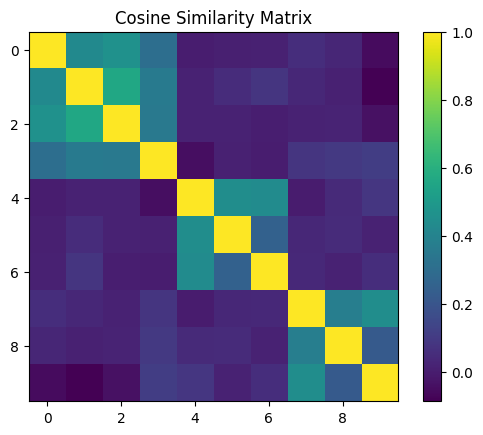


Top 2 similar sentences:
The bowler took three wickets in one over -> Score: 1.0000001
The batsman scored a century -> Score: 0.56027615


In [3]:
# Install library
!pip install -q sentence-transformers

# Imports
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Sentences (10 total, 3 topics)
sentences = [
    "Cricket is a popular sport in India",
    "The bowler took three wickets in one over",
    "The batsman scored a century",
    "The team won the match easily",
    "Cooking requires fresh ingredients",
    "Boiling water is the first step in many recipes",
    "Spices add flavor to food",
    "Cybersecurity protects systems from hackers",
    "Encryption secures sensitive data",
    "Firewalls prevent unauthorized access"
]

# Load model & generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

# Cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)
print("Similarity Matrix:\n", similarity_matrix)

# Heatmap
plt.imshow(similarity_matrix)
plt.title("Cosine Similarity Matrix")
plt.colorbar()
plt.show()

# Query similarity
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])
similarities = cosine_similarity(query_embedding, embeddings)[0]

# Top 2 results
top_indices = similarities.argsort()[-2:][::-1]

print("\nTop 2 similar sentences:")
for i in top_indices:
    print(sentences[i], "-> Score:", similarities[i])